<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png" width="250" style="display: block; margin-left: auto; margin-right: auto;">

# Premier League – Data Preparation and Feature Engineering

## Purpose

This notebook turns the main EDA findings into one clear and reproducible preprocessing workflow. The priority is to understand **what each step does and why it is necessary**.

By the end, we will be able to:

- validate the minimum input-data contract;
- create the temporal train / test partition without fitting transformations beforehand;
- create a small set of features justified by the EDA;
- impute, encode, and scale different types of variables;
- assemble all transformations into a scikit-learn pipeline;
- prepare the handoff to model comparison without consulting the test set.

```text
Raw data
    ↓
Anomaly correction + validation
    ↓
Temporal train / test
    ↓
Feature engineering
    ↓
Imputation + encoding + scaling
    ↓
Model
```

> Reusable code lives in `src/preprocessing.py` and `src/team_history.py` so the modeling notebook can rebuild the same pipeline without importing a notebook. This notebook is the deliverable: it shows the design, runs it, and reads the output.

> **Test-set limitation:** the earlier EDA inspected the complete dataset, which includes the 2025-2026 season. The test partition created here is useful for the course workflow, but it is not a perfectly untouched final test set.

## 1. Imports and project paths

Dependencies should be installed from the project environment, not from a `pip install` cell inside the notebook.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET_COLUMN = "FTR"
CUTOFF = pd.Timestamp("2025-08-01")

# Allow execution from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "premier_league_2021_2026.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import (
    ALLOWED_RAW_COLUMNS,
    BASE_FEATURES,
    CAL_KEEP,
    CLUB_COLS,
    DOW_KEEP,
    FeatureBuilder,
    HIST_KEEP,
    MARKET_KEEP,
    POST_MATCH_COLUMNS,
    REQUIRED_COLUMNS,
    build_inventory,
    build_model_pipeline,
    build_preprocessor,
)

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.14.6
pandas: 3.0.5
scikit-learn: 1.9.1


## 2. Load and validate the raw data

The EDA identified the expected columns and valid ranges. We now convert those observations into executable checks. If the input schema changes, the notebook should stop with an informative message instead of silently ignoring the problem.

The raw frame has 157 columns, so `X = df` would hand every one of them to the model. Section 7 replaces that with an explicit whitelist; this section only checks that the frame is sound.

In [2]:
df = pd.read_csv(DATA_PATH)

missing_columns = [
    column for column in REQUIRED_COLUMNS if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not df[TARGET_COLUMN].isin(["H", "D", "A"]).all():
    raise ValueError("FTR must contain only H, D or A.")

if (df["HomeTeam"] == df["AwayTeam"]).any():
    raise ValueError("HomeTeam must differ from AwayTeam.")

primary_key = ["Season", "HomeTeam", "AwayTeam"]

if df.duplicated(subset=primary_key).any():
    raise ValueError(f"{primary_key} must be unique.")

if not df.groupby("Season").size().eq(380).all():
    raise ValueError("Every season must contain 380 matches.")

print(f"Validated dataset: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Validated dataset: 1900 rows and 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,...,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-2022,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Correct one reproducible anomaly

The EDA found exactly one internally inconsistent row: `AST > AS` in Newcastle - West Ham on 15/08/2021. Shots on target cannot exceed total shots. The real value of `AS` is 18, verified against an external source. The match key is asserted to match exactly one row before anything is written.

In [3]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

match_key = (
    (df["Date"] == "2021-08-15")
    & (df["HomeTeam"] == "Newcastle")
    & (df["AwayTeam"] == "West Ham")
)

if int(match_key.sum()) != 1:
    raise ValueError(
        f"Expected exactly 1 Newcastle-West Ham row, got {int(match_key.sum())}"
    )

df.loc[match_key, "AS"] = 18

if not df["AST"].le(df["AS"]).all():
    raise ValueError("AST must not exceed AS.")

if not df["HST"].le(df["HS"]).all():
    raise ValueError("HST must not exceed HS.")

numeric_block = df.select_dtypes(include="number").to_numpy(dtype=float)

if np.isinf(numeric_block).any():
    raise ValueError("Infinite values in the numeric block.")

nan_cells = int(np.isnan(numeric_block).sum())
print(f"Anomaly corrected, invariants hold, {nan_cells} missing cells.")

Anomaly corrected, invariants hold, 86394 missing cells.


## 3. Separate the target and create the temporal partitions

We split before fitting imputers, encoders, scalers, or models. The split is a **date cutoff**, not a random sample, because the problem is to predict a season the model has not seen. The home-win rate ranges from 40.79 % to 48.42 % across the five seasons, an amplitude of 7.63 pp that is wider than the 5 pp noise threshold of the EDA, so a random split would mix seasons with different profiles and the test set would stop measuring what we care about.

`stratify` is not an option here: replicating the test season's proportions inside the training set would reproduce exactly the distribution the training set must ignore. The drift between the two halves is information, not a defect to correct.

In [4]:
is_test = df["Date"] >= CUTOFF
df_train = df.loc[~is_test].copy()
df_test = df.loc[is_test].copy()

assert len(df_train) + len(df_test) == len(df)
assert set(df_train.index).isdisjoint(df_test.index)
assert df_train["Date"].max() < df_test["Date"].min()
assert df_train["Season"].nunique() == 4
assert df_test["Season"].nunique() == 1
assert (len(df_train), len(df_test)) == (1520, 380)
assert df_train["Date"].max() < CUTOFF <= df_test["Date"].min()

print(f"Train rows: {len(df_train)} ({df_train['Date'].min():%Y-%m-%d} to {df_train['Date'].max():%Y-%m-%d})")
print(f"Test rows: {len(df_test)} ({df_test['Date'].min():%Y-%m-%d} to {df_test['Date'].max():%Y-%m-%d})")

Train rows: 1520 (2021-08-13 to 2025-05-25)
Test rows: 380 (2025-08-15 to 2026-05-24)


The test season is harder than the training seasons: it has 4.34 pp more draws and 1.91 pp fewer home wins. We print the full distribution rather than hiding it, because that difference is the evidence that the temporal cut is meaningful.

In [5]:
season_share = (
    100
    * pd.crosstab(df["Season"], df[TARGET_COLUMN], normalize="index")
    .round(2)
    .add_suffix(" %")
)
season_share

FTR,A %,D %,H %
Season,,,
2021-2022,34.0,23.0,43.0
2022-2023,29.0,23.0,48.0
2023-2024,32.0,22.0,46.0
2024-2025,35.0,24.0,41.0
2025-2026,30.0,27.0,43.0


## 4. Problem, target distribution and reference accuracy

**What is predicted.** `FTR` is a 3-class classification with a closed domain `{H, D, A}`, one row per match. The natural primary key is `(Season, HomeTeam, AwayTeam)`.

**Prediction instant T-0.** T-0 is the kickoff whistle. At T-0 we know the date, the kickoff time, home and away status, both club identities and every odds quote. We do **not** know the result, the half-time score or any in-match statistic. A feature that carries information from after T-0 would make the model unusable at the moment it is needed, even if it scored well in this notebook.

Closing odds (the `C` columns) *are* available at T-0. They are excluded by redundancy, not by leakage, and we say so rather than inventing a cleaner-sounding excuse.

The draw keeps 454 observations, so no class is empty and no minority is negligible. No oversampling or undersampling is applied; the natural distribution is what the model should learn.

In [6]:
def market_probabilities(frame, cols=("AvgH", "AvgD", "AvgA")):
    """Return de-vigged 1X2 probabilities, one row per match."""
    inverse = 1.0 / frame[list(cols)].to_numpy(dtype=float)
    return inverse / inverse.sum(axis=1, keepdims=True)


classes = np.array(["H", "D", "A"])
target_share = df[TARGET_COLUMN].value_counts(normalize=True)

print("Target distribution (n=1900)")
print((100 * target_share).round(2).rename("share %"))

trivial_accuracy = 100 * target_share.max()
print(f"\nTrivial baseline (always {target_share.idxmax()}): {trivial_accuracy:.2f} %")

favorite = classes[market_probabilities(df).argmax(axis=1)]
market_accuracy = 100 * (favorite == df[TARGET_COLUMN].to_numpy()).mean()
print(f"Market baseline (de-vig + favourite): {market_accuracy:.2f} %")

Target distribution (n=1900)
FTR
H    44.16
A    31.95
D    23.89
Name: share %, dtype: float64

Trivial baseline (always H): 44.16 %
Market baseline (de-vig + favourite): 55.32 %


The de-vig formula and its assumption:

```text
p_i = (1 / o_i) / sum_j (1 / o_j)   for i in {home, draw, away}
```

We assume the bookmaker margin is proportional and split equally across the three outcomes. That is a **method decision, not a truth**: the real margin could follow Gibbs or Shin. The proportional version is chosen because it is the one the EDA measured.

Two reference scores frame everything that follows. A pipeline that does not beat the trivial baseline is not learning; a pipeline that does not beat the market is worse than publishing the price. One detail hides inside the market figure: the market **never picks the draw**. Out of 1900 matches the de-vig chooses H 1194 times, A 706 times and D zero times, so its 55.32 % comes with no coverage at all of the minority class. That is the concrete margin where a model can add value.

## 5. Translate EDA findings into preparation decisions

Every feature in this notebook originates in one row of this table. The evidence column is mandatory: a row without a number is not a decision.

| EDA finding | Evidence | Decision in this baseline | Rejected alternative |
| --- | --- | --- | --- |
| Target is imbalanced but not extreme | H 44.16 %, D 23.89 %, A 31.95 % (n=1900) | 3-class target, report per-season shares | Oversampling or undersampling |
| A trivial baseline is easy to beat | Majority class = 44.16 % | 44.16 % is the floor to clear | Reporting accuracy without a floor |
| The market already holds most of the signal | de-vig favourite = 55.32 % | 55.32 % is the value threshold | Treating 52 % accuracy as a success |
| The home advantage is already implied | +12.2 pp, IC95 [9.1, 15.3] (n=3800) | No `IsHome` column | A constant dummy adds no degrees of freedom |
| Class balance shifts across seasons | H from 40.79 % to 48.42 % (7.63 pp) | Split on a date cutoff | Random split |
| The test season is harder than training | D +4.34 pp, A -2.43 pp, H -1.91 pp | Print the drift, do not rebalance | Stratifying to equalise |
| Handicap is the strongest pre-match signal | `AHh < -1.8` → 88.9 % home wins (n=90); `AHh > +1.3` → 4.5 % (n=67) | Keep `AHh` as a numeric column | Dropping it as a duplicate of `AvgH` |
| Main bookmaker families are complete | `B365*`, `Avg*`, `Max*`, `PS*` 0 % missing | Build the market block from `AvgH/D/A` only | Keeping 18 correlated book columns |
| Secondary quote families are structurally empty | `CLCH/D/A` 1640 missing; `1XB*` 1529 (n=1900) | Exclude them; summarise as `OddsQuotes` | Imputing 1640 cells with the median |
| An availability flag on `B365H` is dead | `B365H` 0 % missing over 1900 rows | Build `OddsQuotes` from the 42 exchange quotes | An indicator with zero variance |
| Match statistics are complete but post-match | 12 columns, 0 % missing (n=1900) | Exclude them from the input frame | Treating completeness as permission |
| Missingness concentrates in few families | 95 of 157 columns have at least one missing | Impute with the **train** median and report it | Imputing with a global or literal constant |
| One club is new in the test season | 27 clubs total; Sunderland only in 2025-26 (38 matches); 7 clubs only in train | One-hot with `handle_unknown="ignore"` | Letting `transform` raise on test |
| Seven clubs disappear from the test season | 14 one-hot columns are zero in test | Report the zero-variance count | Deleting them by hand |
| Fixture congestion is high and direction is unclear | `FTR=H` in the congestion window 33.7 % (n=184) vs 45.3 % elsewhere (n=1716) | Use `RestDays` only | Adding a global congestion index |
| The matchday calendar is regular | 380 = 20 teams x 19 matchdays x 10 matches | Use `Home/Away_MatchesPlayed` | Using the matchday number |
| One internally inconsistent row | `AST > AS` in Newcastle - West Ham, 15/08/2021 | Correct `AS` to 18 and assert the invariant | Leaving it and polluting the rolling window |

The 157 raw columns are classified by family. The inventory is **generated** from a family dictionary plus per-column exceptions, so a typo becomes an execution error instead of a mislabelled column.

In [7]:
inventory = build_inventory(df.columns)
inventory["accion"].value_counts().rename("columns").to_frame()

,columns
accion,
excluir,152
transformar,4
target,1


## 6. Create understandable features

`FeatureBuilder` combines the historical block from `src/team_history.py` with the market and calendar features. It is **stateless with respect to the raw row**: it learns no median and no category frequency. It does read the label, but through `y` rather than through `X`, and it returns an explicit projection of the allowed columns, so `FTR` cannot reach the model.

The historical block applies `shift(1)` inside `(Team, Season)` before the rolling window, so a match never contributes to its own features and the summer break is never counted as league congestion. The `NaN` on a season opener is left in place: a fresh pre-season is not any particular number of rest days, and imputing a constant would invent a value that never existed.

In [8]:
X_train = df_train.loc[:, ALLOWED_RAW_COLUMNS]
X_test = df_test.loc[:, ALLOWED_RAW_COLUMNS]
y_train = df_train[TARGET_COLUMN]
y_test = df_test[TARGET_COLUMN]

feature_builder = FeatureBuilder().fit(X_train, y_train)
preview = feature_builder.transform(X_train)

print(f"Built {preview.shape[0]} rows x {preview.shape[1]} columns")
preview.head()

Built 1520 rows x 25 columns


,Home_Hist_Pts_k,Away_Hist_Pts_k,Diff_Hist_Pts_k,Home_Hist_GF_k,Away_Hist_GF_k,Diff_Hist_GF_k,Home_Hist_GA_k,Away_Hist_GA_k,Home_Hist_W_k,Away_Hist_W_k,...,p_draw,p_away,Mkt_Gap,AHh,Home_MatchesPlayed,Away_MatchesPlayed,OddsQuotes,DayOfWeek,HomeTeam,AwayTeam
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.281591,0.478147,2.00,0.50,0,0,0,4,Brentford,Arsenal
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.214891,0.164005,-4.32,-1.00,0,0,0,5,Man United,Leeds
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.311564,0.386639,0.70,0.25,0,0,0,5,Burnley,Brighton
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.162314,0.075070,-11.54,-1.50,0,0,0,5,Chelsea,Crystal Palace
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.272804,0.238366,-2.07,-0.50,0,0,0,5,Everton,Southampton


The first rows of a season are the check worth reading: a home team on its opener has `NaN` in `Home_Hist_Pts_k` and `Home_RestDays`, while the away team already has values. That is exactly the expected asymmetry.

In [9]:
preview[[
    "Home_Hist_Pts_k",
    "Away_Hist_Pts_k",
    "Diff_Hist_Pts_k",
    "Home_RestDays",
    "Away_RestDays",
    "p_home",
    "Mkt_Gap",
    "Home_MatchesPlayed",
    "OddsQuotes",
]].head()

,Home_Hist_Pts_k,Away_Hist_Pts_k,Diff_Hist_Pts_k,Home_RestDays,Away_RestDays,p_home,Mkt_Gap,Home_MatchesPlayed,OddsQuotes
0,NaN,NaN,NaN,NaN,NaN,0.240263,2.00,0,0
1,NaN,NaN,NaN,NaN,NaN,0.621104,-4.32,0,0
2,NaN,NaN,NaN,NaN,NaN,0.301797,0.70,0,0
3,NaN,NaN,NaN,NaN,NaN,0.762616,-11.54,0,0
4,NaN,NaN,NaN,NaN,NaN,0.488831,-2.07,0,0


## 7. Group features by the transformation they need

A `ColumnTransformer` lets us apply a different preparation strategy to each variable type.

| Group | Columns | Preparation |
| --- | --- | --- |
| Historical | 14 (`HIST_KEEP`) | Median imputation and standardisation |
| Market | 5 (`MARKET_KEEP`) | Median imputation and standardisation |
| Calendar | 3 (`CAL_KEEP`) | Median imputation and standardisation |
| Clubs | 2 (`CLUB_COLS`) | One-hot, `handle_unknown="ignore"` |
| Day of week | 1 (`DOW_KEEP`) | One-hot, `handle_unknown="ignore"` |

`X` is a **positive whitelist** of 53 raw columns, taken with `df.loc[:, ALLOWED_RAW_COLUMNS]` rather than `df.drop(...)`. Subtracting a list is as fragile as adding one, and the resulting matrix would not be auditable. `remainder="drop"` is the second line of defence, not the first: if a column ever reaches the whitelist by mistake, its block discards it.

The 17 post-match columns never enter. `FTHG` and `FTAG` are the deliberate exception: they are the results of *earlier* matches, available at T-0, and `shift(1)` guarantees a row never consumes its own result.

In [10]:
print(f"Raw columns allowed: {len(ALLOWED_RAW_COLUMNS)}")
print(f"Post-match columns allowed: {sorted(set(ALLOWED_RAW_COLUMNS) & set(POST_MATCH_COLUMNS))}")
print(f"Base features: {len(BASE_FEATURES)}")
assert "FTR" not in ALLOWED_RAW_COLUMNS
assert "HTR" not in ALLOWED_RAW_COLUMNS
assert set(X_train.columns) <= set(ALLOWED_RAW_COLUMNS)

Raw columns allowed: 53
Post-match columns allowed: ['FTAG', 'FTHG']
Base features: 23


## 8. Build the numeric and categorical pipelines

**Numeric columns.** `SimpleImputer(strategy="median")` learns a median from training data only. `StandardScaler()` centres and scales the result, which linear and distance-based models need.

**Categorical columns.** One-hot encoding creates indicator columns, and `handle_unknown="ignore"` means a club that never appears in training does not raise at inference; its row simply loses that one indicator and keeps the rest of its information.

In [11]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

print("Numeric and categorical pipelines built.")

Numeric and categorical pipelines built.


## 9. Combine the transformations with `ColumnTransformer`

`remainder="drop"` means that only the explicitly listed features reach the model. This makes feature selection visible and auditable. `verbose_feature_names_out=False` keeps the output names bare, so the containment check in section 11 is a real test rather than a tautology.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("historical", numeric_pipeline, HIST_KEEP),
        ("market", numeric_pipeline, MARKET_KEEP),
        ("calendar", numeric_pipeline, CAL_KEEP),
        ("clubs", categorical_pipeline, CLUB_COLS),
        ("day_of_week", categorical_pipeline, DOW_KEEP),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

print("ColumnTransformer built.")

ColumnTransformer built.


## 10. Put feature engineering inside the preparation pipeline

Although we previewed the engineered features earlier, the real workflow must recreate them inside the pipeline. This ensures that the same code is applied during training, validation, test evaluation, and future inference.

`fit_transform` below is used only as a structural demonstration on training data. During model comparison, the complete pipeline must be fitted separately inside every cross-validation fold.

In [13]:
preparation_pipeline = Pipeline(
    steps=[
        ("feature_engineering", FeatureBuilder()),
        ("preprocessor", preprocessor),
    ]
)

X_train_prepared = preparation_pipeline.fit_transform(X_train, y_train)
output_feature_names = list(
    preparation_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

print(f"Raw training shape: {X_train.shape}")
print(f"Prepared training shape: {X_train_prepared.shape}")

Raw training shape: (1520, 53)
Prepared training shape: (1520, 81)


Most of the growth in width comes from the one-hot of clubs, not from the 23 base features. That is expected and worth stating, because a reviewer counting columns should know where they come from.

In [14]:
pd.DataFrame(
    {
        "output_feature": output_feature_names,
        "block": [
            "one_hot" if name.startswith(("HomeTeam_", "AwayTeam_", "DayOfWeek_"))
            else "numeric"
            for name in output_feature_names
        ],
    }
)

,output_feature,block
0,Home_Hist_Pts_k,numeric
1,Away_Hist_Pts_k,numeric
2,Diff_Hist_Pts_k,numeric
3,Home_Hist_GF_k,numeric
4,Away_Hist_GF_k,numeric
...,...,...
76,DayOfWeek_2,one_hot
77,DayOfWeek_3,one_hot
78,DayOfWeek_4,one_hot
79,DayOfWeek_5,one_hot


### Structural and leakage checks

These checks verify that the number of matches did not change, that every output value is finite, that no post-match column reached the output, and that the imputers learned the **training** median rather than a global one.

In [15]:
assert X_train_prepared.shape[0] == X_train.shape[0]
assert X_train_prepared.shape[1] == len(output_feature_names)
assert np.isfinite(X_train_prepared.to_numpy(dtype=float)).all()

bare_allowed = set(HIST_KEEP + MARKET_KEEP + CAL_KEEP)
prefixes = ("HomeTeam_", "AwayTeam_", "DayOfWeek_")

assert all(
    name in bare_allowed or name.startswith(prefixes)
    for name in output_feature_names
), "a column outside the contract reached the output"

assert not set(output_feature_names) & set(POST_MATCH_COLUMNS)
assert "FTR" not in output_feature_names

for block in ("historical", "market", "calendar"):
    imputer = preprocessor.named_transformers_[block].named_steps["imputer"]
    columns = {
        "historical": HIST_KEEP,
        "market": MARKET_KEEP,
        "calendar": CAL_KEEP,
    }[block]
    for value, column in zip(imputer.statistics_, columns):
        train_median = np.nanmedian(preview[column].astype(float))
        if not np.isclose(value, train_median):
            raise ValueError(f"{column}: median is not the training median")

print("All structural and leakage checks passed.")

All structural and leakage checks passed.


### The historical block never reads the test season

This is the numerical counterpart of the EDA-bias acknowledgement in the introduction. Because `shift(1)` runs inside `(Team, Season)`, every training row consumes only earlier training rows. We prove it rather than assert it: the block computed over all 1900 rows must equal the block computed over the 1520 training rows alone.

In [16]:
frame_before = df_train.loc[:, ALLOWED_RAW_COLUMNS].copy(deep=True)

hist_all = FeatureBuilder().fit(
    df.loc[:, ALLOWED_RAW_COLUMNS],
    df[TARGET_COLUMN],
).transform(df.loc[:, ALLOWED_RAW_COLUMNS])
from_full = (
    hist_all.loc[~is_test.to_numpy()]
    .reset_index(drop=True)
    .loc[:, HIST_KEEP]
)

hist_train_only = (
    FeatureBuilder()
    .fit(X_train, y_train)
    .transform(X_train)
    .reset_index(drop=True)
    .loc[:, HIST_KEEP]
)

pd.testing.assert_frame_equal(from_full, hist_train_only)
pd.testing.assert_frame_equal(frame_before, X_train)

print("Historical block identical on 1900 rows and on 1520 rows.")
print("The pipeline did not mutate the input frame.")

Historical block identical on 1900 rows and on 1520 rows.
The pipeline did not mutate the input frame.


## 11. Build the future raw-data-to-model pipeline

The modeling notebook will supply an estimator. `clone` creates an unfitted copy so that different experiments do not share learned state. The model will therefore receive raw match rows; feature engineering, imputation, encoding, scaling, and prediction remain together.

Nothing is fitted here. This section only demonstrates the signature the modeling notebook will call.

In [17]:
model_pipeline = build_model_pipeline(DummyClassifier())

print([name for name, _ in model_pipeline.steps])
assert not hasattr(model_pipeline.steps[-1][1], "classes_")
print("Estimator arrives unfitted; the modeling notebook owns the fit.")

['feat', 'prep', 'model']
Estimator arrives unfitted; the modeling notebook owns the fit.


## 12. Visual checks

Three figures carry the evidence that the tables state numerically. Each one names its units on the axis.

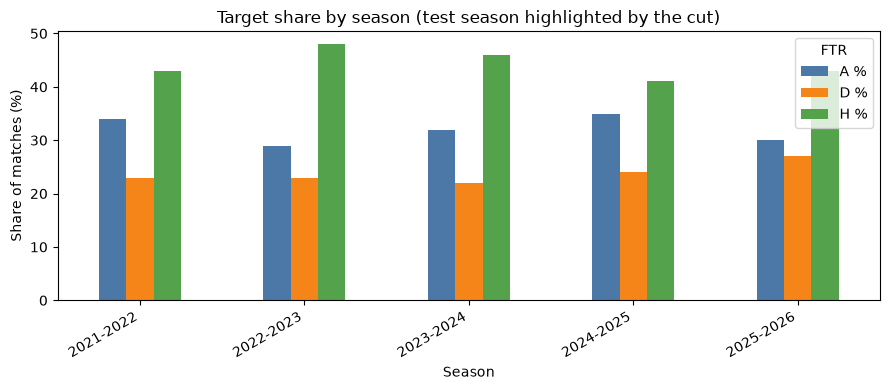

In [18]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ax = season_share.plot.bar(
    figsize=(9, 4),
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set(
    title="Target share by season (test season highlighted by the cut)",
    xlabel="Season",
    ylabel="Share of matches (%)",
)
ax.legend(title="FTR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_share_by_season.png")
plt.show()

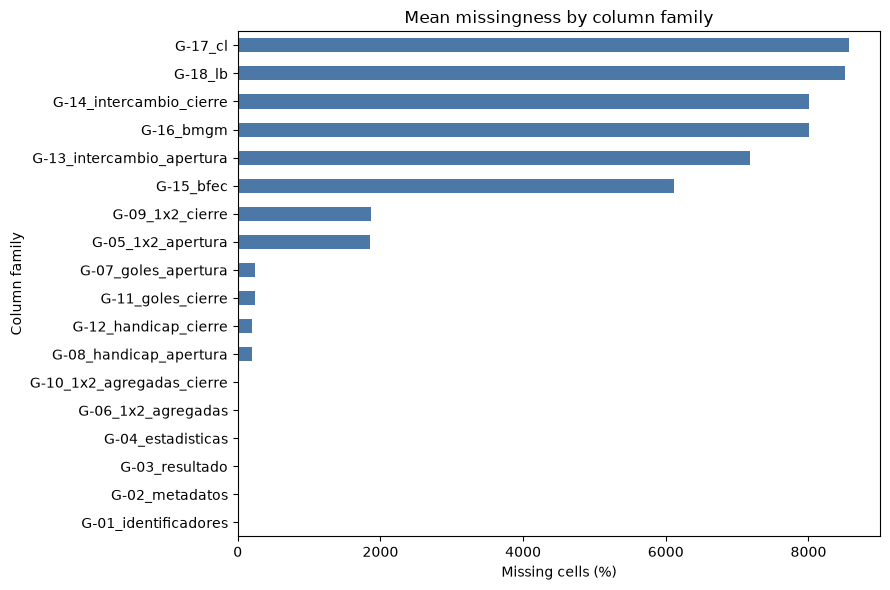

In [19]:
missing_share = (
    100 * inventory.merge(
        df.isna().mean().mul(100).rename("missing_pct"),
        left_on="columna",
        right_index=True,
    )
    .groupby("familia")["missing_pct"]
    .mean()
    .sort_values()
)

ax = missing_share.plot.barh(figsize=(9, 6), color="#4C78A8")
ax.set(
    title="Mean missingness by column family",
    xlabel="Missing cells (%)",
    ylabel="Column family",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missingness_by_family.png")
plt.show()

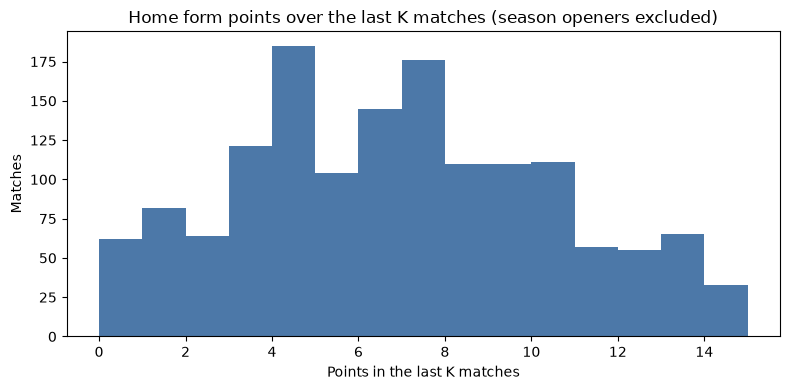

Season openers without history: 40 of 1520 training rows


In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(preview["Home_Hist_Pts_k"].dropna(), bins=15, color="#4C78A8")
ax.set(
    title="Home form points over the last K matches (season openers excluded)",
    xlabel="Points in the last K matches",
    ylabel="Matches",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "home_form_points.png")
plt.show()

print(
    f"Season openers without history: {int(preview['Home_Hist_Pts_k'].isna().sum())}"
    f" of {len(preview)} training rows"
)

## 13. Save a readable split manifest

We save match-to-partition assignments so that another notebook can reproduce the exact split. We do **not** save the transformed matrix: the final model pipeline must learn its preprocessing inside cross-validation.

In [21]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

key_columns = ["Season", "HomeTeam", "AwayTeam", "Date"]

train_manifest = df_train[key_columns].copy()
train_manifest["split"] = "train"

test_manifest = df_test[key_columns].copy()
test_manifest["split"] = "test"

split_manifest = pd.concat([train_manifest, test_manifest], ignore_index=True)
split_manifest = split_manifest.sort_values(["Season", "Date", "HomeTeam"])

split_manifest.to_csv(ARTIFACTS_DIR / "split_assignments.csv", index=False)
split_manifest.head()

,Season,HomeTeam,AwayTeam,Date,split
0,2021-2022,Brentford,Arsenal,2021-08-13,train
2,2021-2022,Burnley,Brighton,2021-08-14,train
3,2021-2022,Chelsea,Crystal Palace,2021-08-14,train
4,2021-2022,Everton,Southampton,2021-08-14,train
5,2021-2022,Leicester,Wolves,2021-08-14,train


## 14. Save minimal reproducibility metadata

At this stage there is no selected fitted model, so we do not serialize a production pipeline. We save only the information needed to reproduce the split and the environment.

In [22]:
metadata = {
    "random_state": RANDOM_STATE,
    "cutoff": str(CUTOFF.date()),
    "target_column": TARGET_COLUMN,
    "primary_key": ["Season", "HomeTeam", "AwayTeam"],
    "train_rows": len(df_train),
    "test_rows": len(df_test),
    "trivial_baseline_pct": round(float(trivial_accuracy), 2),
    "market_baseline_pct": round(float(market_accuracy), 2),
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "test_note": (
        "The previous EDA inspected the complete dataset, including "
        "2025-2026. Treat this as a test set, not an untouched final test."
    ),
}

metadata_path = ARTIFACTS_DIR / "data_preparation_metadata.json"

with metadata_path.open("w", encoding="utf-8") as metadata_file:
    json.dump(metadata, metadata_file, indent=2)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: C:\Users\user\Documents\Github\premier_league_football_predictor\reports\data_preparation_metadata.json


## 15. Handoff to modeling

The modeling notebook should:

1. use only `X_train` and `y_train` for cross-validation and model selection;
2. compare complete pipelines created with `build_model_pipeline`;
3. clear both baselines from section 4 before claiming a result;
4. select metrics before inspecting model results;
5. evaluate the test set only after selecting the complete pipeline.

### Check your understanding

- Why is `AvgH` used instead of the 18 individual book columns?
- Why is the split a date cutoff rather than a stratified sample?
- What does `shift(1)` protect the historical block from?
- Why does `Home_Hist_Pts_k` stay `NaN` on a season opener?
- What does `handle_unknown="ignore"` protect us from on the Sunderland rows?
- Why must the imputer learn its median from training data only?